<a href="https://colab.research.google.com/github/RashfiTabassum/People-Flow-Detection-using-Object-Tracking-Heatmap-Visualization/blob/main/People_Flow_Detection_using_Object_Tracking_%26_Heatmap_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## https://drive.google.com/drive/folders/1yTDR1lQEk1QOLmRDKlbCJF3wANTL5FbU?usp=sharing


In [ ]:
!pip install -q ultralytics supervision opencv-python-headless matplotlib numpy pillow
# ultralytics provides detection + built-in tracking


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 7.7 MB/s eta 0:00:00


In [ ]:
#imports & configuration
import cv2
import numpy as np
from ultralytics import YOLO
import time, os
from IPython.display import Video, Image, display
import matplotlib.pyplot as plt

#VIDEO / MODEL
VIDEO_URL = "https://media.roboflow.com/supervision/video-examples/people-walking.mp4"
MODEL_PATH = "yolov8n.pt"   # quick test model;
TRACKER_CFG = "botsort.yaml"  # tracker used by ultralytics.track

#REFERENCE annotated coords (from Roboflow PolygonZone)
ANNOT_W, ANNOT_H = 1125, 632  # example reference size used when we drew lines in Roboflow

#the start/end coordinates line coordinates of the two horizontal lines.
ANNOT_LINE_IN_START = (0, 207)
ANNOT_LINE_IN_END   = (1125, 207)
ANNOT_LINE_OUT_START= (0, 427)
ANNOT_LINE_OUT_END  = (1125, 427)

#COUNTING / FILTER
CLASS_PERSON_ID = 0    # COCO id for 'person'
CONFIDENCE_THRESHOLD = 0.5

#OUTPUT
OUTPUT_VIDEO = "people_flow_output.mp4"
HEATMAP_IMAGE = "people_flow_heatmap.png"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# helpers (drawing, centers, gaussian spot for heatmap)
def scale_point(pt, orig_w, orig_h, annot_w=ANNOT_W, annot_h=ANNOT_H):
    x, y = pt
    return (int(x * orig_w / annot_w), int(y * orig_h / annot_h))

def draw_count_lines(frame, line1_pts, line2_pts, color1=(255,0,0), color2=(0,0,255)):
    h, w = frame.shape[:2]
    cv2.line(frame, line1_pts[0], line1_pts[1], color1, 2)
    cv2.putText(frame, "UPPER LINE", (10, max(10, line1_pts[0][1]-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color1, 2)
    cv2.line(frame, line2_pts[0], line2_pts[1], color2, 2)
    cv2.putText(frame, "LOWER LINE", (10, max(30, line2_pts[0][1]-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color2, 2)

def box_center(x1,y1,x2,y2):
    return ((x1+x2)//2, (y1+y2)//2)

def add_gaussian(acc, cx, cy, radius=12, value=1.0):
    """Add small gaussian blob to accumulator acc around (cx,cy). acc is float32."""
    h, w = acc.shape
    x0, x1 = max(0, cx-radius), min(w, cx+radius+1)
    y0, y1 = max(0, cy-radius), min(h, cy+radius+1)
    if x0>=x1 or y0>=y1:
        return
    gx = np.arange(x0, x1) - cx
    gy = np.arange(y0, y1) - cy
    sigma = max(radius/2.5, 1.0)
    gx2 = gx**2; gy2 = gy**2
    Gx = np.exp(-gx2 / (2*sigma*sigma))
    Gy = np.exp(-gy2 / (2*sigma*sigma))
    patch = np.outer(Gy, Gx)
    acc[y0:y1, x0:x1] += patch * value


helpers are used to scale polygon points to the real video frame size, draw the two lines, compute box centers, and put small Gaussian blobs into a heatmap accumulator.

### **gives different colored boxes**

In [ ]:
def process_video(video_path=VIDEO_URL, output_path=OUTPUT_VIDEO, heatmap_path=HEATMAP_IMAGE,
                  model_path=MODEL_PATH, tracker_cfg=TRACKER_CFG):
    # Load YOLO model
    print("[*] Loading model:", model_path)
    model = YOLO(model_path) #This model can detect objects (person here) in each video frame.

    # Open video
    cap = cv2.VideoCapture(video_path) #this function opens the video file or URL.
    if not cap.isOpened():
        raise RuntimeError("Failed to open video.")

    ret, first_frame = cap.read() #reads the first frame (an image) from the video.
    if not ret:
        cap.release()
        raise RuntimeError("Failed to read first frame.")
    orig_h, orig_w = first_frame.shape[:2] #gives height and width of the video frame.

    # Scale the lines according to video size
    # The original lines were drawn on a reference image (ANNOT_W, ANNOT_H).
    # scale_point() adjusts their coordinates to match the actual video size, so counting works correctly.
    LINE_IN_START  = scale_point(ANNOT_LINE_IN_START, orig_w, orig_h)
    LINE_IN_END    = scale_point(ANNOT_LINE_IN_END, orig_w, orig_h)
    LINE_OUT_START = scale_point(ANNOT_LINE_OUT_START, orig_w, orig_h)
    LINE_OUT_END   = scale_point(ANNOT_LINE_OUT_END, orig_w, orig_h)

    # Video writer
    OUT_W, OUT_H = 960, int(960 * orig_h / orig_w) # Sets output resolution: width = 960, height scaled to keep aspect ratio.
    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), 20, (OUT_W, OUT_H))# the params denote (Save frames to this file, compress with this codec, play at this FPS, and resize frames to this resolution)
    #codec means how frames are compressed.

    # Heatmap accumulator for presence/movement (full-res, centers)
    # Creates a blank 2D array (same size as video) to store people’s positions.
    # Every time a person is detected, a small “glow” (Gaussian blob) is added here.
    # Later this becomes the movement heatmap.
    acc_presence = np.zeros((orig_h, orig_w), dtype=np.float32)  # Full-res for accuracy


    #so till this part code reads the first frame, figures out frame size, scales counting lines, sets up the output video, and prepares a blank heatmap for tracking people’s movement.




    # Counting & tracking
    in_count = 0
    out_count = 0
    counted_in = set() #remember which person IDs have already been counted (avoid double counting).
    counted_out = set()
    track_history = {}  # track_id -> list of recent centers. stores last few positions of each tracked person (by their id)
    direction_state = {}  # stores whether each person has gone IN or OUT (for coloring).

    results_stream = model.track(source=video_path, tracker=tracker_cfg, persist=True, stream=True)#Runs YOLO + BoT-SORT tracker on the video.
    #Returns a stream of results frame by frame (res).


    frame_idx = 0 #Initializes a frame counter.
    start_time = time.time() #Records the start time which is Later used to calculate how much time has passed while processing frames.
    for res in results_stream: #Loops through each result object from model.track().Each res contains information about one frame, including:the image itself (res.orig_img),detected boxes (res.boxes),tracker IDs, etc.
        if not hasattr(res, "orig_img") or res.orig_img is None: #Equivalent to asking: “Does this frame object contain the original image?”
            continue #go to nxt frame if The image is None (empty frame).
        frame = res.orig_img.copy() #Makes a copy of the frame image so we can draw on it (lines, boxes, heatmap) without changing the original data.
        frame_idx += 1

        boxes = getattr(res, "boxes", None) #checks if obj has an attribute attr.If yes → returns it; if no → returns default (here None).
        if boxes is None or boxes.xyxy is None: #If there are no boxes detected:
            draw_count_lines(frame, (LINE_IN_START, LINE_IN_END), (LINE_OUT_START, LINE_OUT_END)) #Draw the counting lines (upper/lower).
            cv2.putText(frame, f"In: {in_count}", (10,40), cv2.FONT_HERSHEY_SIMPLEX,1.1,(0,255,0),3) #Display current IN/OUT counts on the frame.
            cv2.putText(frame, f"Out: {out_count}", (10,100), cv2.FONT_HERSHEY_SIMPLEX,1.1,(0,0,255),3) #(10,40) (10,100) are coordinates where the texts will be shown
            writer.write(cv2.resize(frame, (OUT_W, OUT_H))) #Save the frame to the output video.
            continue

        xyxy = boxes.xyxy.cpu().numpy().astype(int) #tensor of bounding box coordinates [x1, y1, x2, y2],move tensor to CPU and convert to NumPy array,convert coordinates to integers.
        cls = boxes.cls.cpu().numpy().astype(int) #class IDs of detected objects Converted to NumPy integers.
        ids = [None]*len(xyxy) # Initialize ids as None for all boxes.
        if hasattr(boxes, "id") and boxes.id is not None:
            try:
                ids = boxes.id.cpu().numpy().astype(int) #If the tracker assigned IDs (boxes.id) → convert to NumPy int array.Tracker IDs allow tracking the same person across frames.
            except:
                pass

        person_indices = [i for i, c in enumerate(cls) if c == CLASS_PERSON_ID] #indexes of people in the current frame.Only keep boxes where cls == CLASS_PERSON_ID (0)

        for i in person_indices: #Loop through each detected person
            x1, y1, x2, y2 = xyxy[i] #x1, y1 → top-left corner and x2, y2 → bottom-right corner of bounding box.
            tid = ids[i] # tracker ID of this person (unique across frames).
            cx, cy = box_center(x1, y1, x2, y2) # center of bounding box

            # Update track history. track_history → dictionary: track_id -> list of recent centers.
            if tid is not None:
                history = track_history.get(tid, []) #get current history for this ID, or empty list if not exists.
                history.append((cx, cy)) #add current center.
                if len(history) > 4:
                    history = history[-4:] #keep only last 4 positions.Why last 4?Enough to determine movement direction without memory growing indefinitely.
                track_history[tid] = history

            # Counting logic
            if tid is not None and len(track_history[tid]) >= 2: #Only consider IDs with at least 2 positions
                prev_x, prev_y = track_history[tid][-2] #previous center.
                curr_x, curr_y = track_history[tid][-1] #current center.

                # IN: moving down and crosses upper line
                if (LINE_IN_START[0] <= prev_x <= LINE_IN_END[0] and LINE_IN_START[0] <= curr_x <= LINE_IN_END[0]): #Ensures the person’s x-position (left-right) is within the line boundaries
                    if prev_y < LINE_IN_START[1] <= curr_y and tid not in counted_in: #Checks that the person was above the line in the previous frame (prev_y < line_y) And below or on the line in the current frame (curr_y >= line_y).
                        in_count += 1 # "tid not in counted_in" Ensures the person is counted only once.
                        counted_in.add(tid)
                        direction_state[tid] = "IN"
                        cv2.putText(frame, "IN", (curr_x+5, curr_y-5),
                                    cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,0,0),2)

                # OUT: moving up and crosses lower line
                if (LINE_OUT_START[0] <= prev_x <= LINE_OUT_END[0] and
                    LINE_OUT_START[0] <= curr_x <= LINE_OUT_END[0]): #Similar logic as IN but for upward movement across lower line.
                    if prev_y > LINE_OUT_START[1] >= curr_y and tid not in counted_out:
                        out_count += 1
                        counted_out.add(tid)
                        direction_state[tid] = "OUT"
                        cv2.putText(frame, "OUT", (curr_x+5, curr_y-5),
                                    cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,0,255),2)

            # Add to presence heatmap (at center, uniform weight)
            add_gaussian(acc_presence, cx, cy, radius=15, value=1.0) # 2D array storing density of detected people.
            #cx, cy → center of current person’s bounding box; radius=15 → size of the Gaussian “blob” added.;value=1.0 → intensity of this blob.


            # Color-coded bounding boxes
            color = (255, 255, 255)  # default white
            if tid in direction_state:
                if direction_state[tid] == "IN":
                    color = (255, 0, 0)     # Blue for IN (BGR)
                elif direction_state[tid] == "OUT":
                    color = (255, 0, 255)   # Pink for OUT (BGR)

            cv2.rectangle(frame, (x1,y1),(x2,y2), color, 2) #Draws a rectangle around the person.
            cv2.putText(frame, f"ID {tid}" if tid is not None else "ID -", #(x1, max(10, y1-6)) → position slightly above top-left of the box.
                        (x1,max(10,y1-6)), cv2.FONT_HERSHEY_SIMPLEX,0.5, color, 2) #Displays the tracker ID above the box.0.5 → font scale, color → same as box, 2 → thickness.
            cv2.circle(frame,(cx,cy),3,(0,255,0),-1) #Draws a small green circle at the center of the bounding box. 3 → radius of the circle; (0,255,0) → green in BGR; -1 → filled circle.

        # Draw lines and counts
        draw_count_lines(frame, (LINE_IN_START, LINE_IN_END), (LINE_OUT_START, LINE_OUT_END)) Draws the upper (IN) and lower (OUT) lines on the frame.
        cv2.putText(frame, f"In: {in_count}", (10,40),
                    cv2.FONT_HERSHEY_SIMPLEX,1.1,(255,0,0),3) #Displays the current counts of people who went IN or OUT.
        cv2.putText(frame, f"Out: {out_count}", (10,100),
                    cv2.FONT_HERSHEY_SIMPLEX,1.1,(255,0,255),3)

        writer.write(cv2.resize(frame, (OUT_W, OUT_H))) #Resizes the frame to the output video size & Writes it to the output video file.

        if frame_idx % 200 == 0: #Print progress every 200 frames
            elapsed = time.time() - start_time
            print(f"Processed frames: {frame_idx}, In: {in_count}, Out: {out_count}, elapsed: {elapsed:.1f}s")

    # Cleanup
    writer.release() #Releases video writer and video capture resources.
    cap.release()
    print("[*] Finished processing. IN:", in_count, "OUT:", out_count) # Prints the final IN/OUT counts.

    # Build presence/movement heatmap using bounding box centers
    acc_blur = cv2.GaussianBlur(acc_presence, (51, 51), sigmaX=15)  # Blur the accumulated heatmap (acc_presence) to make smooth density regions.acc_presence → input heatmap,(51, 51) → size of blur kernel (odd numbers, bigger = more blur),sigmaX=15 → spread of blur in X direction (larger = smoother).sigmaY defaults to the same value as sigmaX.Omitting sigmaY just makes the blur symmetric, same horizontally and vertically.
    acc_norm = cv2.normalize(acc_blur / frame_idx, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) #Scales the heatmap values to 0–255 for visualization.
    acc_colored = cv2.applyColorMap(acc_norm, cv2.COLORMAP_VIRIDIS)  # Converts normalized heatmap to a color image for better visualization.. input grayscale image (0–255).Viridis converts grayscale to colored heatmap (blue → yellow).
    overlay_presence = cv2.addWeighted(first_frame, 0.5, acc_colored, 0.5, 0) #Combines frame + heatmap 50% each, so the heatmap appears semi-transparent.first_frame → first frame of the video (background), 0.5 → weight of the first frame, acc_colored → the heatmap image to overlay, 0.5 → weight of the heatmap,0 → scalar added to result (usually 0).
    presence_heatmap_path = "presence_heatmap.png"  # New output file for this heatmap
    cv2.imwrite(presence_heatmap_path, overlay_presence) #Writes the final heatmap overlay as an image file.
    print("[*] Saved presence/movement heatmap (bounding box centers) to", presence_heatmap_path)

    # (Optional: Keep old directional heatmap if needed, but omitted here for focus)

    return output_path, presence_heatmap_path

so the steps in this function are:

* Open video & YOLO model.
* Scale counting lines & initialize video writer & heatmap.
* Loop over frames: detect people, track IDs, count IN/OUT, update heatmap, draw boxes/lines/counts, save frame.
* After all frames: create a smoothed color heatmap and save.
* Return paths of processed video & heatmap.

In [ ]:
# Run the pipeline
out_video_path, heatmap_path = process_video()
print("Output video:", out_video_path)
print("Heatmap:", heatmap_path)


[*] Loading model: yolov8n.pt
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


video 1/1 (frame 1/341) /content/people-walking.mp4: 384x640 37 persons, 2 birds, 367.8ms
video 1/1 (frame 2/341) /content/people-walking.mp4: 384x640 36 persons, 2 birds, 169.5ms
video 1/1 (frame 3/341) /content/people-walking.mp4: 384x640 35 persons, 3 birds, 146.2ms
video 1/1 (frame 4/341) /content/people-walking.mp4: 384x640 35 persons, 3 birds, 144.6ms
video 1/1 (frame 5/341) /content/people-walking.mp4: 384x640 34 persons, 2 birds, 145.0ms
video 1/1 (frame 6/341) /content/people-walking.mp4: 384x640 36 persons, 2 birds, 145.8ms
video 1/1 (frame 7/341) /content/people-walking.mp4: 384x640 36 persons, 2 birds, 163.2ms
video 1/1 (frame 8/341) /content/people-walking.mp4: 384x640 37 persons, 2 birds, 147.6ms
video 1/1 (frame 9/341) /content

Displaying final heatmap:


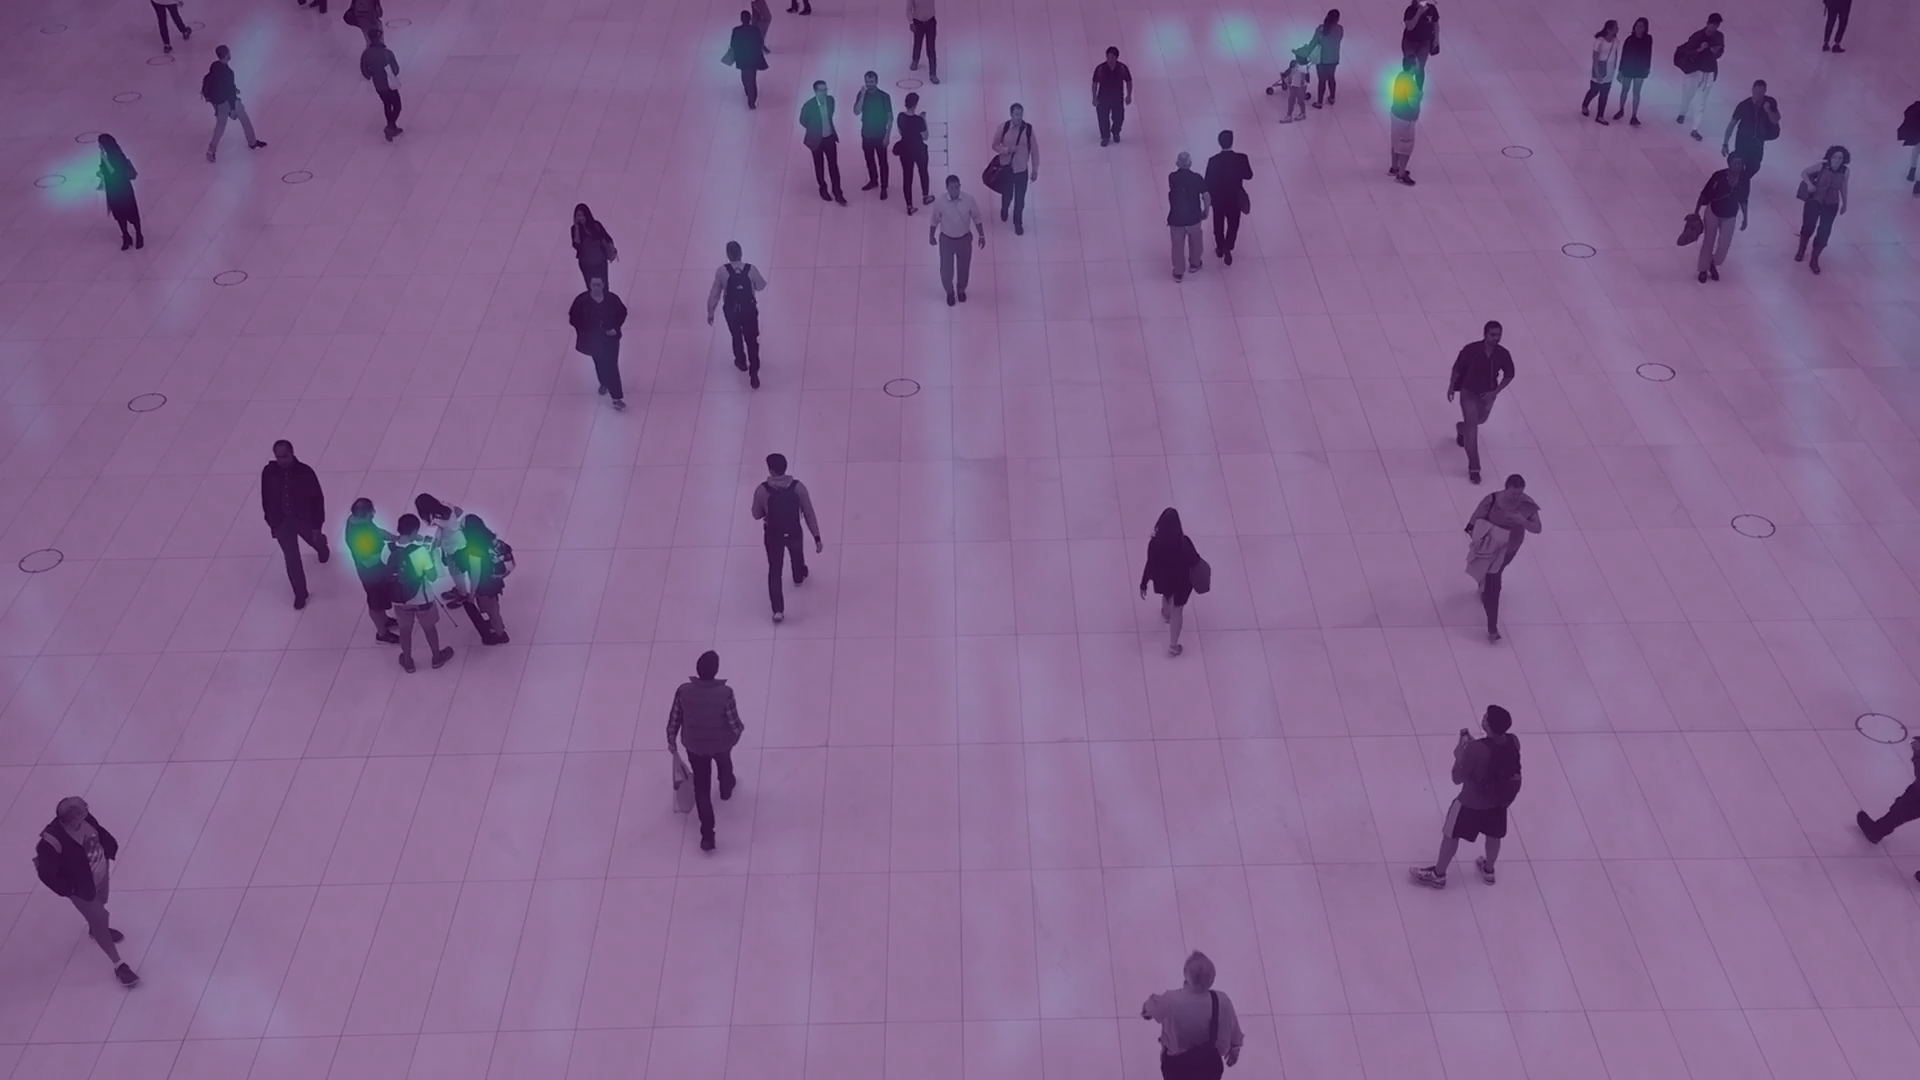


Displaying output video (small embed):


In [ ]:
# display outputs in Colab
from IPython.display import display, Video, Image
import os

print("Displaying final heatmap:")
# Check for the correct heatmap file name
if os.path.exists("presence_heatmap.png"):
    display(Image("presence_heatmap.png"))
else:
    print("Heatmap image not found at", "presence_heatmap.png")

# print("\nDisplaying output video (small embed):")
# if os.path.exists(OUTPUT_VIDEO):
#     display(Video(OUTPUT_VIDEO))
# else:
#     print("Output video not found at", OUTPUT_VIDEO)